In [8]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from neural_capm.data.loaders import load_price_series, compute_returns
from neural_capm.data.preprocessing import build_full_feature_matrix
from neural_capm.evaluation.backtest import chronological_split
from neural_capm.models.sequence_prep import FeatureScaler, create_delta_sequences
from neural_capm.models.lstm_beta import LSTMBetaPredictor

torch.manual_seed(42)
np.random.seed(42)

In [9]:
reliance_prices = load_price_series("RELIANCE.NS")
reliance_ret = compute_returns(reliance_prices)

index_prices = load_price_series("^NSEI")
index_ret = compute_returns(index_prices)

reliance_matrix = build_full_feature_matrix(reliance_ret, index_ret)
reliance_matrix.to_csv("../data/processed/RELIANCE_NS_feature_matrix.csv")

print(reliance_matrix.shape)
reliance_matrix.head()

(2367, 6)


,india_cpi,india_10y_yield,momentum,volatility,lagged_beta,beta_target
2015-05-21,97.92796,7.85218,0.032166,0.016950,1.036319,1.036663
2015-05-22,97.92796,7.85218,0.043541,0.016965,1.036663,1.038104
2015-05-25,97.92796,7.85218,0.030572,0.017198,1.038104,1.037551
2015-05-26,97.92796,7.85218,0.023358,0.017390,1.037551,1.040155
2015-05-27,97.92796,7.85218,0.036123,0.017127,1.040155,1.040078


In [10]:
train_df, val_df, test_df = chronological_split(
    reliance_matrix, train_end="2021-12-31", val_end="2022-12-31"
)

print("Train:", train_df.shape, train_df.index.min(), "to", train_df.index.max())
print("Val:  ", val_df.shape, val_df.index.min(), "to", val_df.index.max())
print("Test: ", test_df.shape, test_df.index.min(), "to", test_df.index.max())


Train: (1629, 6) 2015-05-21 00:00:00 to 2021-12-31 00:00:00
Val:   (248, 6) 2022-01-03 00:00:00 to 2022-12-30 00:00:00
Test:  (490, 6) 2023-01-02 00:00:00 to 2024-12-30 00:00:00


In [11]:
feature_cols = ["india_cpi", "india_10y_yield", "momentum", "volatility", "lagged_beta"]

scaler = FeatureScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

print(train_scaled.shape, val_scaled.shape, test_scaled.shape)

(1629, 5) (248, 5) (490, 5)


In [12]:
SEQUENCE_LENGTH = 30

X_train, y_train_delta, dates_train, prev_beta_train = create_delta_sequences(
    train_scaled, train_df["beta_target"], sequence_length=SEQUENCE_LENGTH
)
X_val, y_val_delta, dates_val, prev_beta_val = create_delta_sequences(
    val_scaled, val_df["beta_target"], sequence_length=SEQUENCE_LENGTH
)
X_test, y_test_delta, dates_test, prev_beta_test = create_delta_sequences(
    test_scaled, test_df["beta_target"], sequence_length=SEQUENCE_LENGTH
)

print("Train sequences:", X_train.shape, y_train_delta.shape)
print("Val sequences:  ", X_val.shape, y_val_delta.shape)
print("Test sequences: ", X_test.shape, y_test_delta.shape)
print("\nDelta target stats (train):", y_train_delta.mean(), y_train_delta.std())

Train sequences: (1598, 30, 5) (1598,)
Val sequences:   (217, 30, 5) (217,)
Test sequences:  (459, 30, 5) (459,)

Delta target stats (train): 2.1332137451655572e-05 0.005454214716532645


In [13]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_delta, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val_delta, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test_delta, dtype=torch.float32)

print(X_train_t.shape, X_val_t.shape, X_test_t.shape)

torch.Size([1598, 30, 5]) torch.Size([217, 30, 5]) torch.Size([459, 30, 5])


In [14]:
N_FEATURES = X_train_t.shape[2]

model = LSTMBetaPredictor(n_features=N_FEATURES, hidden_size=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 200
batch_size = 64
patience = 20

best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None
train_losses, val_losses = [], []

n_train = X_train_t.shape[0]

for epoch in range(n_epochs):
    model.train()
    permutation = torch.randperm(n_train)
    epoch_train_loss = 0.0

    for i in range(0, n_train, batch_size):
        indices = permutation[i:i + batch_size]
        X_batch = X_train_t[indices]
        y_batch = y_train_t[indices]

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * len(indices)

    epoch_train_loss /= n_train
    train_losses.append(epoch_train_loss)

    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val_t)
        val_loss = criterion(val_predictions, y_val_t).item()
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_model_state = model.state_dict()
    else:
        epochs_without_improvement += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train_loss: {epoch_train_loss:.8f} | val_loss: {val_loss:.8f}")

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_model_state)
print(f"\nBest validation loss (on DELTA): {best_val_loss:.8f}")

Epoch   0 | train_loss: 0.00391403 | val_loss: 0.00641249
Epoch  10 | train_loss: 0.00004063 | val_loss: 0.00010582
Epoch  20 | train_loss: 0.00003461 | val_loss: 0.00005861
Epoch  30 | train_loss: 0.00003142 | val_loss: 0.00001751
Epoch  40 | train_loss: 0.00003221 | val_loss: 0.00001324
Epoch  50 | train_loss: 0.00002966 | val_loss: 0.00001335
Epoch  60 | train_loss: 0.00003184 | val_loss: 0.00001269
Early stopping at epoch 69

Best validation loss (on DELTA): 0.00000894


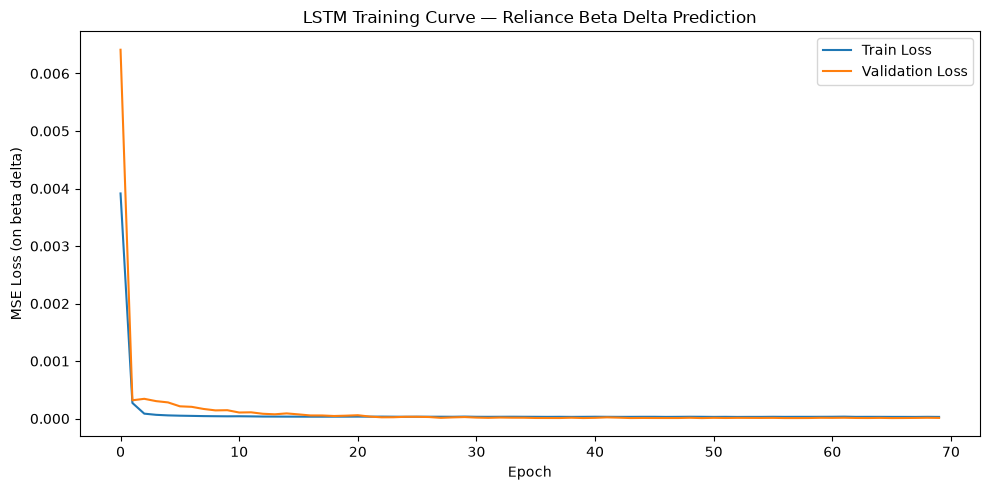

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (on beta delta)")
plt.title("LSTM Training Curve — Reliance Beta Delta Prediction")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/lstm_training_curve_reliance.png", dpi=150)
plt.show()

In [16]:
model.eval()
with torch.no_grad():
    val_delta_pred = model(X_val_t).numpy()

lstm_level_pred = prev_beta_val + val_delta_pred
lstm_level_actual = prev_beta_val + y_val_delta

lstm_mse = np.mean((lstm_level_actual - lstm_level_pred) ** 2)
naive_mean_mse = np.mean((lstm_level_actual - np.full_like(lstm_level_actual, train_df["beta_target"].mean())) ** 2)
naive_persistence_mse = np.mean((lstm_level_actual - prev_beta_val) ** 2)

print(f"Naive mean-prediction MSE:    {naive_mean_mse:.8f}")
print(f"Naive persistence MSE:        {naive_persistence_mse:.8f}")
print(f"LSTM + lagged_beta MSE:       {lstm_mse:.8f}")

Naive mean-prediction MSE:    0.00005483
Naive persistence MSE:        0.00000732
LSTM + lagged_beta MSE:       0.00001193


In [17]:
model.eval()
with torch.no_grad():
    val_delta_pred = model(X_val_t).numpy()

# reconstruct predicted beta LEVEL from predicted delta + previous known beta
lstm_level_pred = prev_beta_val + val_delta_pred
lstm_level_actual = prev_beta_val + y_val_delta  # true level, reconstructed the same way, for a fair apples-to-apples check

lstm_mse = np.mean((lstm_level_actual - lstm_level_pred) ** 2)

# same naive baselines as before, recomputed on this exact same set of dates for a fair comparison
naive_mean_pred = np.full_like(lstm_level_actual, train_df["beta_target"].mean())
naive_mean_mse = np.mean((lstm_level_actual - naive_mean_pred) ** 2)

naive_persistence_mse = np.mean((lstm_level_actual - prev_beta_val) ** 2)  # predicting delta=0, i.e. no change

print(f"Naive mean-prediction MSE:    {naive_mean_mse:.8f}")
print(f"Naive persistence MSE:        {naive_persistence_mse:.8f}")
print(f"LSTM (delta-based) MSE:       {lstm_mse:.8f}")

Naive mean-prediction MSE:    0.00005483
Naive persistence MSE:        0.00000732
LSTM (delta-based) MSE:       0.00001193


In [18]:
model.eval()
with torch.no_grad():
    test_delta_pred = model(X_test_t).numpy()

lstm_level_pred_test = prev_beta_test + test_delta_pred
lstm_level_actual_test = prev_beta_test + y_test_delta

lstm_mse_test = np.mean((lstm_level_actual_test - lstm_level_pred_test) ** 2)
naive_mean_mse_test = np.mean((lstm_level_actual_test - np.full_like(lstm_level_actual_test, train_df["beta_target"].mean())) ** 2)
naive_persistence_mse_test = np.mean((lstm_level_actual_test - prev_beta_test) ** 2)

print(f"[TEST] Naive mean-prediction MSE:    {naive_mean_mse_test:.8f}")
print(f"[TEST] Naive persistence MSE:        {naive_persistence_mse_test:.8f}")
print(f"[TEST] LSTM + lagged_beta MSE:       {lstm_mse_test:.8f}")

[TEST] Naive mean-prediction MSE:    0.00273489
[TEST] Naive persistence MSE:        0.00000604
[TEST] LSTM + lagged_beta MSE:       0.00001052
